# 11b — Key-event acoustic energetics, SPL, and provisional yield

Use the manually reviewed key-event definitions from Notebook 11 to calculate
channel-specific peak sound-pressure levels, sound exposure levels, acoustic
energy fluence, and radiated acoustic energy. Energetics are summarized for
hemispherical and spherical spreading assumptions.

The notebook also expresses radiated acoustic energy as a TNT energy equivalent
and gives an explicitly provisional total-energy-equivalent range for configurable
acoustic efficiencies. It does **not** infer blast yield from peak overpressure;
that requires a cited explosion-specific scaled-distance relation.

## Definitions and interpretation

For pressure relative to the local baseline, peak SPL and sound exposure level are

\[
L_{p,\mathrm{peak}}=20\log_{10}\left(\frac{p_{\mathrm{peak}}}{p_0}\right),
\qquad
L_E=10\log_{10}\left[\frac{\int p^2(t)\,dt}{p_0^2t_0}\right],
\]

where \(p_0=20\ \mu\mathrm{Pa}\) and \(t_0=1\ \mathrm{s}\). Acoustic energy is
approximated as

\[
E_\mathrm{ac}=\frac{\Omega r^2}{\rho c}\int p^2(t)\,dt,
\]

where \(r\) is source–sensor distance, \(\rho\) is moist-air density, \(c\) is
the adopted effective sound speed, and \(\Omega\) is the radiation solid angle.
The primary estimate uses \(\Omega=2\pi\) (hemispherical spreading); \(4\pi\)
is retained as a sensitivity bound.

These are free-field, far-field approximations applied to a complex near-surface
source. Ground reflection, directivity, atmospheric attenuation, waveform
processing, and the finite source all contribute systematic uncertainty. The
TNT equivalent of the radiated acoustic energy is not the same as total explosive
yield. Efficiency-scaled values are included only as transparent scenarios.

In [1]:
from pathlib import Path
import json
import sys

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from obspy import read, UTCDateTime

from modules import project_config as config

DERIVED_DIR = config.NB120_DIR
FIGURE_DIR = config.NB120_DIR
for directory in (DERIVED_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 130,
})

In [2]:
# Inputs produced by Notebooks 02, 03, and 11.
ANALYSIS_CONFIG_FILE = config.NB010_DIR / "analysis_configuration.json"
WEATHER_SUMMARY_FILE = config.NB020_DIR / "weather_acoustic_summary.csv"
WINDOW_FILE = config.NB110_DIR / "key_event_measurement_windows.csv"
NOTEBOOK11_METADATA_FILE = config.NB110_DIR / "key_event_measurement_metadata.json"

for required_file in (
    ANALYSIS_CONFIG_FILE,
    WEATHER_SUMMARY_FILE,
    WINDOW_FILE,
    NOTEBOOK11_METADATA_FILE,
):
    if not required_file.exists():
        raise FileNotFoundError(required_file)

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())
notebook11_metadata = json.loads(NOTEBOOK11_METADATA_FILE.read_text())
weather_summary = pd.read_csv(WEATHER_SUMMARY_FILE).iloc[0]
windows = pd.read_csv(WINDOW_FILE)

baseline_products = analysis_config.get("baseline_removed_streams", {})
PRESSURE_STREAM_FILE = Path(
    baseline_products.get(
        "pickle",
        config.NB010_DIR / "bchh_corrected_moving_median_baseline_removed.pkl",
    )
).expanduser()
if not PRESSURE_STREAM_FILE.exists():
    raise FileNotFoundError(PRESSURE_STREAM_FILE)

pressure_stream = read(str(PRESSURE_STREAM_FILE), format="PICKLE")
PRESSURE_CHANNELS = tuple(analysis_config["pressure_channels"])
SENSOR_DISTANCES_M = {
    str(channel): float(distance)
    for channel, distance in notebook11_metadata["sensor_distances_m"].items()
}

# Travel-time velocity used by Notebook 11. Keep its provenance with the outputs.
EFFECTIVE_SOUND_SPEED_MPS = float(
    notebook11_metadata["acoustic_propagation_speed_mps"]
)
if not np.isclose(EFFECTIVE_SOUND_SPEED_MPS, 351.0, atol=0.1):
    raise ValueError(
        "Notebook 11 output does not use the adopted approximately 351 m/s "
        f"source-to-array effective sound speed: {EFFECTIVE_SOUND_SPEED_MPS:.3f}"
    )

# Moist-air density from Notebook 03 temperature and humidity, using a declared
# near-sea-level pressure. Replace this pressure with a measured value if available.
ATMOSPHERIC_PRESSURE_PA = 101_325.0
temperature_c = float(weather_summary["mean_temperature_c"])
relative_humidity_fraction = (
    float(weather_summary["mean_relative_humidity_percent"]) / 100.0
)
temperature_k = temperature_c + 273.15
saturation_vapor_pressure_pa = 610.94 * np.exp(
    17.625 * temperature_c / (temperature_c + 243.04)
)
vapor_pressure_pa = relative_humidity_fraction * saturation_vapor_pressure_pa
dry_air_pressure_pa = ATMOSPHERIC_PRESSURE_PA - vapor_pressure_pa
AIR_DENSITY_KG_M3 = (
    dry_air_pressure_pa / (287.05 * temperature_k)
    + vapor_pressure_pa / (461.495 * temperature_k)
)

REFERENCE_PRESSURE_PA = 20.0e-6
REFERENCE_EXPOSURE_TIME_S = 1.0
JOULES_PER_KG_TNT = 4.184e6

# Illustrative acoustic-efficiency scenarios, not calibrated blast yields.
ACOUSTIC_EFFICIENCY_REFERENCE = 0.01
ACOUSTIC_EFFICIENCY_RANGE = (0.001, 0.10)

# Notebook 11's first capsule-pulse signal began exactly at the predicted DD2
# arrival and clipped its leading positive peak after adopting 351 m/s. Extend
# this event's energetics interval 0.04 s before the predicted arrival. Other
# events retain their reviewed signal offsets.
SIGNAL_START_OFFSET_OVERRIDES_S = {
    "capsule_impact": -0.04,
}

print("Pressure stream:", PRESSURE_STREAM_FILE)
print(f"Effective sound speed: {EFFECTIVE_SOUND_SPEED_MPS:.3f} m/s")
print(
    f"Air density: {AIR_DENSITY_KG_M3:.4f} kg/m^3 "
    f"at {temperature_c:.2f} °C, "
    f"RH={100*relative_humidity_fraction:.1f}%, "
    f"pressure={ATMOSPHERIC_PRESSURE_PA/100:.2f} hPa"
)
display(windows[[
    "event", "source_event_key", "source_time_utc",
    "signal_start_offset_from_predicted_arrival_s",
    "signal_end_offset_from_predicted_arrival_s",
]])

Pressure stream: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/010_prepare_analysis_inputs/bchh_corrected_moving_median_baseline_removed.pkl
Effective sound speed: 351.000 m/s
Air density: 1.1659 kg/m^3 at 26.36 °C, RH=83.9%, pressure=1013.25 hPa


,event,source_event_key,source_time_utc,signal_start_offset_from_predicted_arrival_s,signal_end_offset_from_predicted_arrival_s
0,Initial second-stage failure,upper_stage,2016-09-01T13:07:11.913000,-0.07,0.48
1,Principal explosion,lower_stage,2016-09-01T13:07:15.513600,-0.70,1.05
2,Capsule pulse 1,capsule_impact,2016-09-01T13:07:24.420000,-0.04,0.33
3,Capsule pulse 2,capsule_explosion,2016-09-01T13:07:24.987500,-0.03,0.27


## Channel-specific integration

Notebook 11 defines each signal interval relative to the predicted DD2 arrival.
Here the same relative offsets are applied to the predicted arrival at each
individual sensor. This prevents the approximately 0.09-s differential travel
time across the array from biasing short-event integrations. A local median
baseline is removed independently from every trace before integration.

In [3]:
def one_trace(stream, channel):
    matches = stream.select(channel=channel)
    if len(matches) != 1:
        raise ValueError(f"Expected one {channel} trace; found {len(matches)}")
    return matches[0]


def level_db(numerator, denominator):
    if not np.isfinite(numerator) or numerator <= 0:
        return np.nan
    return float(10.0 * np.log10(numerator / denominator))


energetics_rows = []
waveform_records = {}

for window in windows.itertuples(index=False):
    source_time = UTCDateTime(window.source_time_utc)
    source_key = str(window.source_event_key)

    reference_arrival = UTCDateTime(window.predicted_reference_arrival_utc)
    window_start = UTCDateTime(window.window_start_utc)
    window_start_offset_s = float(window_start - reference_arrival)

    baseline_start_offset_s = window_start_offset_s + float(window.baseline_start_s)
    baseline_end_offset_s = window_start_offset_s + float(window.baseline_end_s)
    signal_start_offset_s = float(
        SIGNAL_START_OFFSET_OVERRIDES_S.get(
            source_key,
            window.signal_start_offset_from_predicted_arrival_s,
        )
    )
    signal_end_offset_s = float(window.signal_end_offset_from_predicted_arrival_s)

    if not baseline_start_offset_s < baseline_end_offset_s <= signal_start_offset_s:
        raise ValueError(
            f"Baseline/signal overlap for {window.event}: "
            f"baseline={baseline_start_offset_s, baseline_end_offset_s}, "
            f"signal={signal_start_offset_s, signal_end_offset_s}"
        )
    if signal_start_offset_s >= signal_end_offset_s:
        raise ValueError(f"Empty signal interval for {window.event}")

    waveform_records[str(window.event)] = []

    for channel in PRESSURE_CHANNELS:
        distance_m = float(SENSOR_DISTANCES_M[channel])
        predicted_arrival = source_time + distance_m / EFFECTIVE_SOUND_SPEED_MPS
        trace = one_trace(pressure_stream, channel)
        times_s = np.asarray(trace.times(reftime=predicted_arrival), dtype=float)
        data_pa = np.asarray(trace.data, dtype=float)

        finite = np.isfinite(times_s) & np.isfinite(data_pa)
        baseline_mask = (
            finite
            & (times_s >= baseline_start_offset_s)
            & (times_s <= baseline_end_offset_s)
        )
        signal_mask = (
            finite
            & (times_s >= signal_start_offset_s)
            & (times_s <= signal_end_offset_s)
        )
        if baseline_mask.sum() < 3 or signal_mask.sum() < 3:
            raise ValueError(
                f"Insufficient samples for {window.event} {channel}: "
                f"baseline={baseline_mask.sum()}, signal={signal_mask.sum()}"
            )

        baseline_pa = float(np.nanmedian(data_pa[baseline_mask]))
        pressure_pa = data_pa - baseline_pa
        signal_time_s = times_s[signal_mask]
        signal_pressure_pa = pressure_pa[signal_mask]

        positive_peak_pa = float(np.nanmax(signal_pressure_pa))
        negative_peak_pa = float(np.nanmin(signal_pressure_pa))
        absolute_peak_pa = float(np.nanmax(np.abs(signal_pressure_pa)))
        peak_to_peak_pa = positive_peak_pa - negative_peak_pa

        pressure_squared_exposure_pa2_s = float(
            np.trapezoid(signal_pressure_pa**2, signal_time_s)
        )
        acoustic_energy_fluence_j_m2 = (
            pressure_squared_exposure_pa2_s
            / (AIR_DENSITY_KG_M3 * EFFECTIVE_SOUND_SPEED_MPS)
        )
        acoustic_energy_2pi_j = (
            2.0 * np.pi * distance_m**2 * acoustic_energy_fluence_j_m2
        )
        acoustic_energy_4pi_j = 2.0 * acoustic_energy_2pi_j

        peak_spl_db = level_db(
            absolute_peak_pa**2,
            REFERENCE_PRESSURE_PA**2,
        )
        positive_peak_spl_db = level_db(
            positive_peak_pa**2,
            REFERENCE_PRESSURE_PA**2,
        )
        negative_peak_spl_db = level_db(
            abs(negative_peak_pa)**2,
            REFERENCE_PRESSURE_PA**2,
        )
        sound_exposure_level_db = level_db(
            pressure_squared_exposure_pa2_s,
            REFERENCE_PRESSURE_PA**2 * REFERENCE_EXPOSURE_TIME_S,
        )

        acoustic_tnt_equivalent_2pi_kg = (
            acoustic_energy_2pi_j / JOULES_PER_KG_TNT
        )
        total_tnt_reference_kg = (
            acoustic_tnt_equivalent_2pi_kg / ACOUSTIC_EFFICIENCY_REFERENCE
        )
        total_tnt_lower_kg = (
            acoustic_tnt_equivalent_2pi_kg / max(ACOUSTIC_EFFICIENCY_RANGE)
        )
        total_tnt_upper_kg = (
            acoustic_tnt_equivalent_2pi_kg / min(ACOUSTIC_EFFICIENCY_RANGE)
        )

        energetics_rows.append({
            "event": str(window.event),
            "source_event_key": source_key,
            "source_time_utc": source_time.isoformat(),
            "channel": channel,
            "distance_m": distance_m,
            "predicted_arrival_utc": predicted_arrival.isoformat(),
            "baseline_start_offset_s": baseline_start_offset_s,
            "baseline_end_offset_s": baseline_end_offset_s,
            "signal_start_offset_s": signal_start_offset_s,
            "signal_end_offset_s": signal_end_offset_s,
            "signal_duration_s": signal_end_offset_s - signal_start_offset_s,
            "baseline_pa": baseline_pa,
            "positive_peak_pa": positive_peak_pa,
            "negative_peak_pa": negative_peak_pa,
            "absolute_peak_pa": absolute_peak_pa,
            "peak_to_peak_pa": peak_to_peak_pa,
            "positive_peak_spl_db": positive_peak_spl_db,
            "negative_peak_spl_db": negative_peak_spl_db,
            "peak_spl_db": peak_spl_db,
            "pressure_squared_exposure_pa2_s": pressure_squared_exposure_pa2_s,
            "sound_exposure_level_db": sound_exposure_level_db,
            "acoustic_energy_fluence_j_m2": acoustic_energy_fluence_j_m2,
            "acoustic_energy_2pi_j": acoustic_energy_2pi_j,
            "acoustic_energy_4pi_j": acoustic_energy_4pi_j,
            "acoustic_tnt_equivalent_2pi_kg": acoustic_tnt_equivalent_2pi_kg,
            "illustrative_total_tnt_at_reference_efficiency_kg": total_tnt_reference_kg,
            "illustrative_total_tnt_lower_kg": total_tnt_lower_kg,
            "illustrative_total_tnt_upper_kg": total_tnt_upper_kg,
        })

        plot_mask = (
            finite
            & (times_s >= baseline_start_offset_s)
            & (times_s <= signal_end_offset_s)
        )
        cumulative = np.zeros(signal_mask.sum(), dtype=float)
        if cumulative.size > 1:
            increments = (
                0.5
                * (signal_pressure_pa[1:]**2 + signal_pressure_pa[:-1]**2)
                * np.diff(signal_time_s)
            )
            cumulative[1:] = np.cumsum(increments)
        cumulative_energy_j = (
            2.0 * np.pi * distance_m**2
            * cumulative / (AIR_DENSITY_KG_M3 * EFFECTIVE_SOUND_SPEED_MPS)
        )
        waveform_records[str(window.event)].append({
            "channel": channel,
            "time_s": times_s[plot_mask],
            "pressure_pa": pressure_pa[plot_mask],
            "signal_time_s": signal_time_s,
            "cumulative_energy_j": cumulative_energy_j,
            "signal_start_offset_s": signal_start_offset_s,
            "signal_end_offset_s": signal_end_offset_s,
        })

energetics_by_channel = pd.DataFrame(energetics_rows)
if len(energetics_by_channel) != len(windows) * len(PRESSURE_CHANNELS):
    raise RuntimeError("Incomplete channel-event energetics table")

display(energetics_by_channel)

,event,source_event_key,source_time_utc,channel,distance_m,predicted_arrival_utc,baseline_start_offset_s,baseline_end_offset_s,signal_start_offset_s,signal_end_offset_s,...,peak_spl_db,pressure_squared_exposure_pa2_s,sound_exposure_level_db,acoustic_energy_fluence_j_m2,acoustic_energy_2pi_j,acoustic_energy_4pi_j,acoustic_tnt_equivalent_2pi_kg,illustrative_total_tnt_at_reference_efficiency_kg,illustrative_total_tnt_lower_kg,illustrative_total_tnt_upper_kg
0,Initial second-stage failure,upper_stage,2016-09-01T13:07:11.913000,DD1,1439.963831,2016-09-01T13:07:16.015461,-0.82,-0.12,-0.07,0.48,...,125.291957,155.535446,115.897694,0.380061,4.951492e+06,9.902985e+06,1.183435,118.343507,11.834351,1183.435068
1,Initial second-stage failure,upper_stage,2016-09-01T13:07:11.913000,DD2,1408.338457,2016-09-01T13:07:15.925360,-0.82,-0.12,-0.07,0.48,...,128.239855,105.553474,114.214125,0.257927,3.214328e+06,6.428656e+06,0.768243,76.824280,7.682428,768.242802
2,Initial second-stage failure,upper_stage,2016-09-01T13:07:11.913000,DD3,1412.854330,2016-09-01T13:07:15.938226,-0.82,-0.12,-0.07,0.48,...,125.744250,100.084010,113.983047,0.244562,3.067348e+06,6.134696e+06,0.733114,73.311374,7.331137,733.113740
3,Principal explosion,lower_stage,2016-09-01T13:07:15.513600,DD1,1439.963831,2016-09-01T13:07:19.616061,-1.35,-0.70,-0.70,1.05,...,156.299066,60586.688132,141.803172,148.047443,1.928786e+09,3.857571e+09,460.990812,46099.081219,4609.908122,460990.812185
4,Principal explosion,lower_stage,2016-09-01T13:07:15.513600,DD2,1408.338457,2016-09-01T13:07:19.525960,-1.35,-0.70,-0.70,1.05,...,157.572772,82388.724522,143.138078,201.322111,2.508912e+09,5.017824e+09,599.644350,59964.435006,5996.443501,599644.350060
5,Principal explosion,lower_stage,2016-09-01T13:07:15.513600,DD3,1412.854330,2016-09-01T13:07:19.538826,-1.35,-0.70,-0.70,1.05,...,156.841493,71721.013744,142.535864,175.254879,2.198086e+09,4.396173e+09,525.355258,52535.525804,5253.552580,525355.258035
6,Capsule pulse 1,capsule_impact,2016-09-01T13:07:24.420000,DD1,1439.963831,2016-09-01T13:07:28.522461,-0.12,-0.05,-0.04,0.33,...,142.086790,1529.111799,125.823792,3.736482,4.867948e+07,9.735897e+07,11.634676,1163.467606,116.346761,11634.676063
7,Capsule pulse 1,capsule_impact,2016-09-01T13:07:24.420000,DD2,1408.338457,2016-09-01T13:07:28.432360,-0.12,-0.05,-0.04,0.33,...,142.885312,1782.045712,126.488588,4.354543,5.426708e+07,1.085342e+08,12.970144,1297.014426,129.701443,12970.144263
8,Capsule pulse 1,capsule_impact,2016-09-01T13:07:24.420000,DD3,1412.854330,2016-09-01T13:07:28.445226,-0.12,-0.05,-0.04,0.33,...,142.907025,1762.646236,126.441052,4.307139,5.402111e+07,1.080422e+08,12.911355,1291.135498,129.113550,12911.354985
9,Capsule pulse 2,capsule_explosion,2016-09-01T13:07:24.987500,DD1,1439.963831,2016-09-01T13:07:29.089961,-0.13,-0.03,-0.03,0.27,...,142.687181,1867.603500,126.692247,4.563608,5.945541e+07,1.189108e+08,14.210185,1421.018512,142.101851,14210.185120


In [4]:
SUMMARY_FIELDS = (
    "positive_peak_pa",
    "negative_peak_pa",
    "peak_to_peak_pa",
    "positive_peak_spl_db",
    "peak_spl_db",
    "sound_exposure_level_db",
    "pressure_squared_exposure_pa2_s",
    "acoustic_energy_2pi_j",
    "acoustic_energy_4pi_j",
    "acoustic_tnt_equivalent_2pi_kg",
    "illustrative_total_tnt_at_reference_efficiency_kg",
    "illustrative_total_tnt_lower_kg",
    "illustrative_total_tnt_upper_kg",
)

summary_rows = []
event_order = windows["event"].astype(str).tolist()
for event in event_order:
    subset = energetics_by_channel.loc[energetics_by_channel["event"] == event]
    first = subset.iloc[0]
    row = {
        "event": event,
        "source_event_key": first["source_event_key"],
        "source_time_utc": first["source_time_utc"],
        "channel_count": int(len(subset)),
    }
    for field in SUMMARY_FIELDS:
        values = subset[field].to_numpy(float)
        row[f"median_{field}"] = float(np.nanmedian(values))
        row[f"minimum_{field}"] = float(np.nanmin(values))
        row[f"maximum_{field}"] = float(np.nanmax(values))
    summary_rows.append(row)

energetics_summary = pd.DataFrame(summary_rows)

display_columns = [
    "event", "source_time_utc",
    "median_positive_peak_spl_db",
    "median_sound_exposure_level_db",
    "median_acoustic_energy_2pi_j",
    "minimum_acoustic_energy_2pi_j",
    "maximum_acoustic_energy_2pi_j",
    "median_acoustic_tnt_equivalent_2pi_kg",
    "median_illustrative_total_tnt_at_reference_efficiency_kg",
    "median_illustrative_total_tnt_lower_kg",
    "median_illustrative_total_tnt_upper_kg",
]
display(energetics_summary[display_columns])

,event,source_time_utc,median_positive_peak_spl_db,median_sound_exposure_level_db,median_acoustic_energy_2pi_j,minimum_acoustic_energy_2pi_j,maximum_acoustic_energy_2pi_j,median_acoustic_tnt_equivalent_2pi_kg,median_illustrative_total_tnt_at_reference_efficiency_kg,median_illustrative_total_tnt_lower_kg,median_illustrative_total_tnt_upper_kg
0,Initial second-stage failure,2016-09-01T13:07:11.913000,125.744250,114.214125,3.214328e+06,3.067348e+06,4.951492e+06,0.768243,76.824280,7.682428,768.242802
1,Principal explosion,2016-09-01T13:07:15.513600,156.841493,142.535864,2.198086e+09,1.928786e+09,2.508912e+09,525.355258,52535.525804,5253.552580,525355.258035
2,Capsule pulse 1,2016-09-01T13:07:24.420000,142.885312,126.441052,5.402111e+07,4.867948e+07,5.426708e+07,12.911355,1291.135498,129.113550,12911.354985
3,Capsule pulse 2,2016-09-01T13:07:24.987500,143.287908,127.053191,6.219814e+07,5.945541e+07,6.314804e+07,14.865712,1486.571169,148.657117,14865.711694


## Diagnostic waveforms and cumulative acoustic energy

All traces are shown relative to their own predicted arrival, so coherent signal
morphology can be compared without differential travel-time bias. The cumulative
curves use the primary \(2\pi\) radiation assumption. They should approach a
plateau before the end of the signal interval; failure to do so indicates that
the integration window should be lengthened.

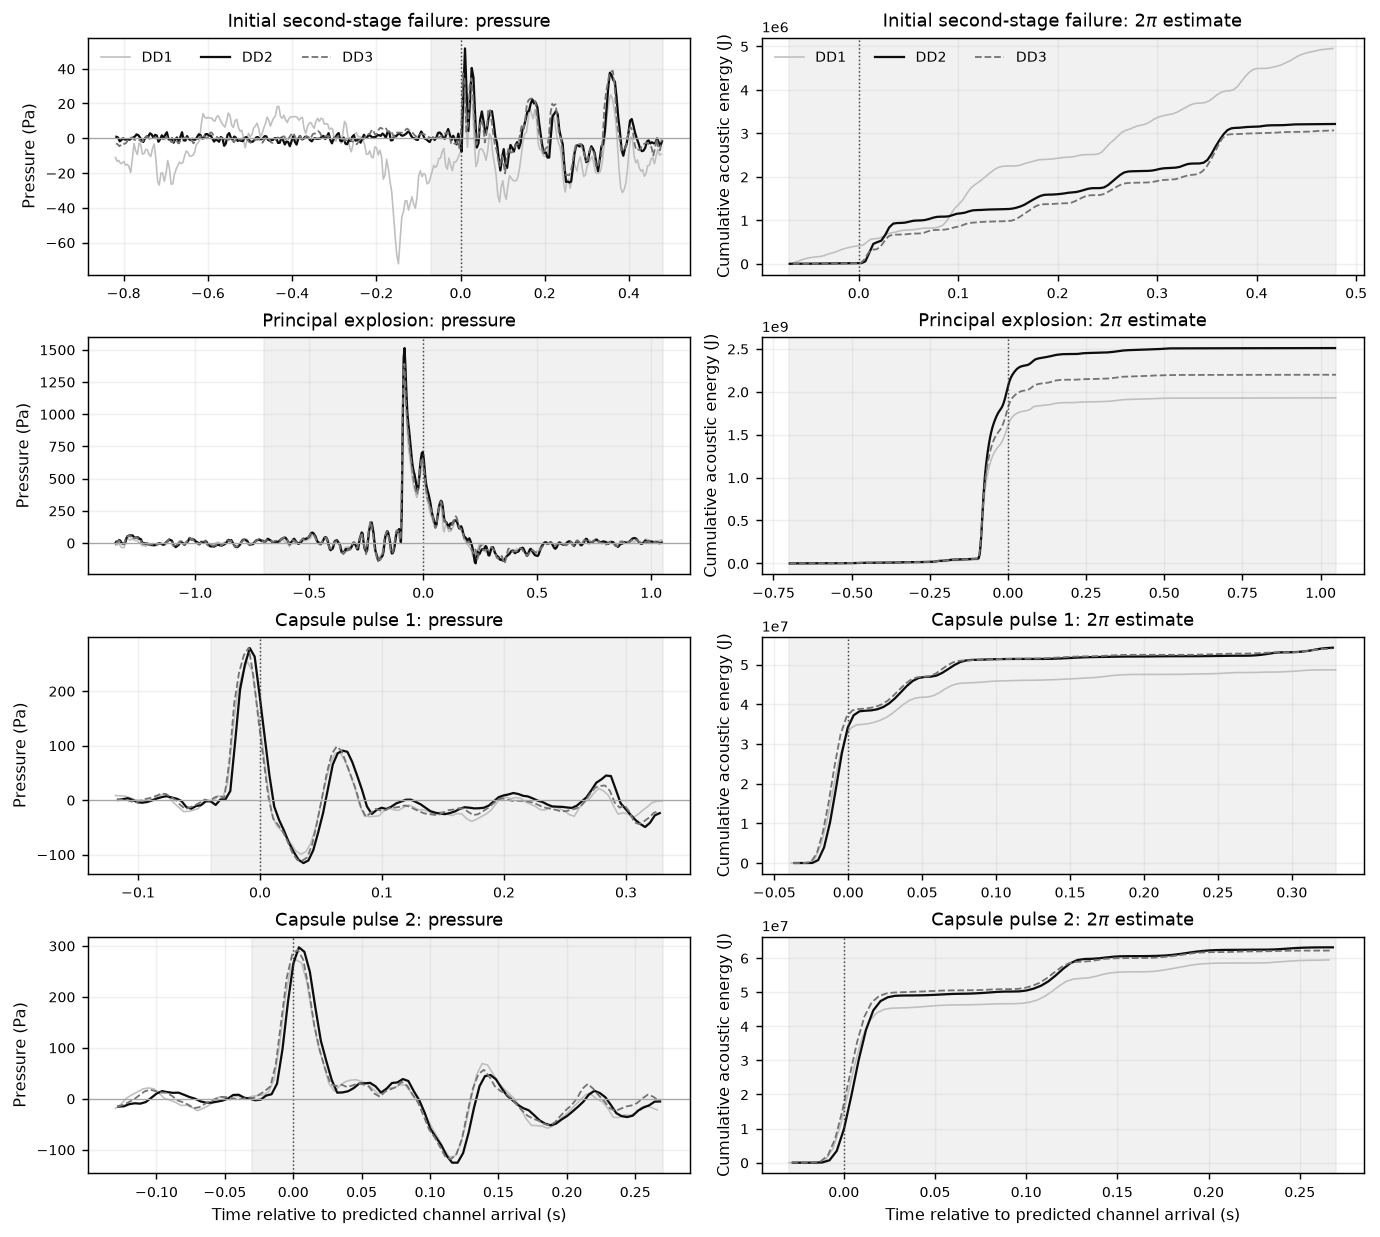

In [5]:
line_styles = {
    "DD1": dict(color="0.75", lw=0.9, ls="-"),
    "DD2": dict(color="0.05", lw=1.25, ls="-"),
    "DD3": dict(color="0.45", lw=1.0, ls="--"),
}

fig, axes = plt.subplots(
    len(event_order), 2,
    figsize=(10.5, 2.35 * len(event_order)),
    constrained_layout=True,
)

for row_index, event in enumerate(event_order):
    ax_wave, ax_energy = axes[row_index]
    records = waveform_records[event]
    signal_start = records[0]["signal_start_offset_s"]
    signal_end = records[0]["signal_end_offset_s"]

    for record in records:
        style = line_styles[record["channel"]]
        ax_wave.plot(
            record["time_s"], record["pressure_pa"],
            label=record["channel"], **style,
        )
        ax_energy.plot(
            record["signal_time_s"], record["cumulative_energy_j"],
            label=record["channel"], **style,
        )

    for ax in (ax_wave, ax_energy):
        ax.axvline(0.0, color="0.25", lw=0.8, ls=":")
        ax.axvspan(signal_start, signal_end, color="0.85", alpha=0.35, zorder=0)
        ax.grid(True, alpha=0.18)

    ax_wave.axhline(0.0, color="0.65", lw=0.7)
    ax_wave.set_ylabel("Pressure (Pa)")
    ax_wave.set_title(f"{event}: pressure")
    ax_energy.set_ylabel("Cumulative acoustic energy (J)")
    ax_energy.set_title(f"{event}: $2\\pi$ estimate")
    if row_index == 0:
        ax_wave.legend(frameon=False, ncol=3, loc="upper left")
        ax_energy.legend(frameon=False, ncol=3, loc="upper left")

axes[-1, 0].set_xlabel("Time relative to predicted channel arrival (s)")
axes[-1, 1].set_xlabel("Time relative to predicted channel arrival (s)")

fig.savefig(
    FIGURE_DIR / "key_event_pressure_and_cumulative_acoustic_energy.pdf",
    dpi=300, bbox_inches="tight",
)
fig.savefig(
    FIGURE_DIR / "key_event_pressure_and_cumulative_acoustic_energy.pdf",
    bbox_inches="tight",
)
plt.show()

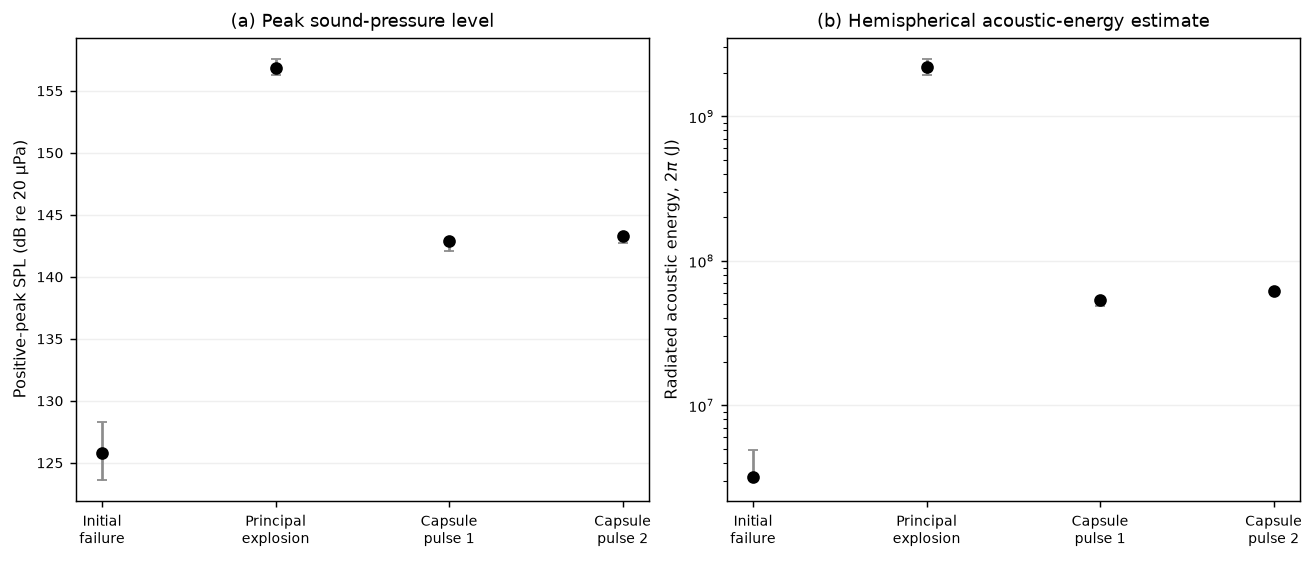

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.2), constrained_layout=True)
x = np.arange(len(energetics_summary))

spl_median = energetics_summary["median_positive_peak_spl_db"].to_numpy(float)
spl_low = energetics_summary["minimum_positive_peak_spl_db"].to_numpy(float)
spl_high = energetics_summary["maximum_positive_peak_spl_db"].to_numpy(float)
axes[0].errorbar(
    x, spl_median,
    yerr=np.vstack([spl_median - spl_low, spl_high - spl_median]),
    fmt="o", color="black", ecolor="0.55", capsize=3,
)
axes[0].set_ylabel("Positive-peak SPL (dB re 20 µPa)")
axes[0].set_title("(a) Peak sound-pressure level")

energy_median = energetics_summary["median_acoustic_energy_2pi_j"].to_numpy(float)
energy_low = energetics_summary["minimum_acoustic_energy_2pi_j"].to_numpy(float)
energy_high = energetics_summary["maximum_acoustic_energy_2pi_j"].to_numpy(float)
axes[1].errorbar(
    x, energy_median,
    yerr=np.vstack([energy_median - energy_low, energy_high - energy_median]),
    fmt="o", color="black", ecolor="0.55", capsize=3,
)
axes[1].set_yscale("log")
axes[1].set_ylabel("Radiated acoustic energy, $2\\pi$ (J)")
axes[1].set_title("(b) Hemispherical acoustic-energy estimate")

short_labels = [
    "Initial\nfailure", "Principal\nexplosion",
    "Capsule\npulse 1", "Capsule\npulse 2",
]
for ax in axes:
    ax.set_xticks(x, short_labels)
    ax.grid(True, axis="y", alpha=0.2)

fig.savefig(
    FIGURE_DIR / "key_event_spl_and_acoustic_energy_summary.pdf",
    dpi=300, bbox_inches="tight",
)
fig.savefig(
    FIGURE_DIR / "key_event_spl_and_acoustic_energy_summary.pdf",
    bbox_inches="tight",
)
plt.show()

## Export and safeguards

The channel table is the authoritative numerical output. The event table reports
the median and channel range. The 2π acoustic energy is the primary estimate;
the 4π value is an explicit geometrical sensitivity result. Efficiency-scaled
TNT values are scenarios, not measured yields, and should not enter the abstract
or conclusions until supported by an appropriate reference and uncertainty model.

In [7]:
CHANNEL_OUTPUT_FILE = DERIVED_DIR / "key_event_acoustic_energetics_by_channel.csv"
SUMMARY_OUTPUT_FILE = DERIVED_DIR / "key_event_acoustic_energetics_summary.csv"
METADATA_OUTPUT_FILE = DERIVED_DIR / "key_event_acoustic_energetics_metadata.json"

energetics_by_channel.to_csv(CHANNEL_OUTPUT_FILE, index=False)
energetics_summary.to_csv(SUMMARY_OUTPUT_FILE, index=False)

metadata = {
    "producer_notebook": "11b_key_event_acoustic_energetics.ipynb",
    "pressure_stream_file": str(PRESSURE_STREAM_FILE),
    "notebook11_window_file": str(WINDOW_FILE),
    "notebook11_metadata_file": str(NOTEBOOK11_METADATA_FILE),
    "weather_summary_file": str(WEATHER_SUMMARY_FILE),
    "pressure_channels": list(PRESSURE_CHANNELS),
    "sensor_distances_m": SENSOR_DISTANCES_M,
    "effective_sound_speed_mps": EFFECTIVE_SOUND_SPEED_MPS,
    "atmospheric_pressure_pa_assumed": ATMOSPHERIC_PRESSURE_PA,
    "mean_temperature_c": temperature_c,
    "mean_relative_humidity_percent": 100.0 * relative_humidity_fraction,
    "computed_air_density_kg_m3": AIR_DENSITY_KG_M3,
    "reference_pressure_pa": REFERENCE_PRESSURE_PA,
    "reference_exposure_time_s": REFERENCE_EXPOSURE_TIME_S,
    "primary_radiation_solid_angle_sr": 2.0 * np.pi,
    "sensitivity_radiation_solid_angle_sr": 4.0 * np.pi,
    "joules_per_kg_tnt": JOULES_PER_KG_TNT,
    "acoustic_efficiency_reference": ACOUSTIC_EFFICIENCY_REFERENCE,
    "acoustic_efficiency_range": list(ACOUSTIC_EFFICIENCY_RANGE),
    "signal_start_offset_overrides_s": SIGNAL_START_OFFSET_OVERRIDES_S,
    "interpretation_warning": (
        "Radiated acoustic-energy TNT equivalent is not total explosive yield. "
        "Efficiency-scaled total equivalents are illustrative scenarios only."
    ),
    "channel_output_file": str(CHANNEL_OUTPUT_FILE),
    "summary_output_file": str(SUMMARY_OUTPUT_FILE),
}
METADATA_OUTPUT_FILE.write_text(json.dumps(metadata, indent=2) + "\n")

print("Wrote:", CHANNEL_OUTPUT_FILE)
print("Wrote:", SUMMARY_OUTPUT_FILE)
print("Wrote:", METADATA_OUTPUT_FILE)

Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/120_estimate_acoustic_energetics/key_event_acoustic_energetics_by_channel.csv
Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/120_estimate_acoustic_energetics/key_event_acoustic_energetics_summary.csv
Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/120_estimate_acoustic_energetics/key_event_acoustic_energetics_metadata.json
